In [1]:
# only if current working directory is not ../AcceleratedPathPatching
import os
path = os.getcwd()
path = path.split("/")
print(path)
path="/".join(path[:-1])

os.chdir("/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching")

['', 'mnt', 'lustre', 'home', 'eickhoff', 'esx670', 'AcceleratedPathPatching', 'Patching']


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import gc
import numpy as np

import torch
import networkx as nx
import huggingface_hub
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from utils.data_io import create_folder, set_PATH

from utils.parser import parser
from utils.data_io import get_base_path



from utils.data_io import create_folder

In [11]:

torch.cuda.empty_cache()
gc.collect()

#################### Parser #####################################

is_notebook = get_ipython()
ipython =  is_notebook is not None

if ipython:
    input_args = [
        # ----- models ------
        #'--model_name=gpt2-large',
        #"--model_name=Qwen/Qwen2.5-7B",
        #"--model_name=Qwen/Qwen2.5-0.5B",
        '--model_name=gpt2',
        
        # ------ dataset arguments --------           
        '--seed=1234',
        '--N=10',  
        '--batch_size=10',
        
        '--metric=kl_divergence',
        # ----- tasks ------
        #'--task=GreaterThan',
        '--task=IOI_test',
        #'--task=GenderedPronouns',
        #'--task=Induction',
        #"--task=Docstring",
        
        '--lowest_sparsity=60', 
        '--highest_sparsity=100', 
        '--cliff_point_list', 'first', 'biggest', 'fixed',
        
        '--step_size=1',
        '--save_every_x_steps=100',
        '--device=cuda',
        "--out_path=/mnt/lustre/work/eickhoff/esx670/res_final/",
        "--cache_dir=/mnt/lustre/work/eickhoff/esx670/llm_weights/",
        
        "--show",
        #"--verbose",
        "--save_text", 
        #"--save_img",
        "--calc_FLOP",
        "--importance_threshold", "3",
        "--min_value_threshold", "0.01"

    ]
args = parser.parse_args(input_args)


# Setting seeds for reproducibility

np.random.seed(args.seed)
torch.random.manual_seed(args.seed)

set_PATH(args.out_path)

#### Just some Printing: Ignore for now

In [6]:
ZERO_ABLATION = False
THRESHOLD = 0.0535
second_metric = None
INDICES_MODE = "reverse"
NAMES_MODE = "normal"
CORRUPTED_CACHE_CPU= False
ONLINE_CACHE_CPU = False
ABS_VALUE_THRESHOLD = True
remove_redundant = False
print(
    "threshold" , THRESHOLD,"\n",

    "zero_ablation", ZERO_ABLATION,"\n",
    "abs_value_threshold", ABS_VALUE_THRESHOLD,"\n",
    "second_metric",second_metric,"\n",
    "verbose",True,"\n",
    "indices_mode",INDICES_MODE,"\n",
    "names_mode",NAMES_MODE,"\n",
    "corrupted_cache_cpu",CORRUPTED_CACHE_CPU,"\n",
    "hook_verbose",True,"\n",
    "online_cache_cpu",ONLINE_CACHE_CPU,"\n",
    "add_sender_hooks",True,"\n",
    "use_pos_embed",False,"\n",
    "add_receiver_hooks",False,"\n",
    "remove_redundant",remove_redundant,"\n",
    "show_full_index",False)

threshold 0.0535 
 zero_ablation False 
 abs_value_threshold True 
 second_metric None 
 verbose True 
 indices_mode reverse 
 names_mode normal 
 corrupted_cache_cpu False 
 hook_verbose True 
 online_cache_cpu False 
 add_sender_hooks True 
 use_pos_embed False 
 add_receiver_hooks False 
 remove_redundant False 
 show_full_index False


## Hybrid FLAP CIRCUIT

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


/mnt/lustre/work/eickhoff/esx670/res_final//gpt2/IOI/path/automatic/maxVal-0.01/importance-3.0/
load gpt2 as CasualLLM adapted to the Llama architecture


GPT2Model2Llama has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


load gpt2 tokenizer
using gpt2 model in IOI dataset


Processing layers: 100%|██████████| 12/12 [00:00<00:00, 53.56it/s]


...

using gpt2 model in IOI dataset


Processing layers: 100%|██████████| 12/12 [00:00<00:00, 49.00it/s]
/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/utils/visualization.py:644: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([0, 1.0, 0.8, 0.6, 0.4, 0.2, 0.0] )


load gpt2 tokenizer
loading gpt2 as HookedTransformer
use float 16
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
using gpt2 model in IOI dataset


/mnt/lustre/home/eickhoff/esx670/AcceleratedPathPatching/Evaluation/findBestCircuit.py:290: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row],  ignore_index=True)


DataFrame saved as results_hybridFLAP.json at /mnt/lustre/work/eickhoff/esx670/res_final//gpt2/IOI/Pruning
DataFrame saved as results_hybridFLAP.json at /mnt/lustre/work/eickhoff/esx670/res_final//gpt2/IOI/Pruning
DataFrame saved as results_hybridFLAP.json at /mnt/lustre/work/eickhoff/esx670/res_final//gpt2/IOI/Pruning
save df at /mnt/lustre/work/eickhoff/esx670/res_final//gpt2/results/PP/PP_df.txt


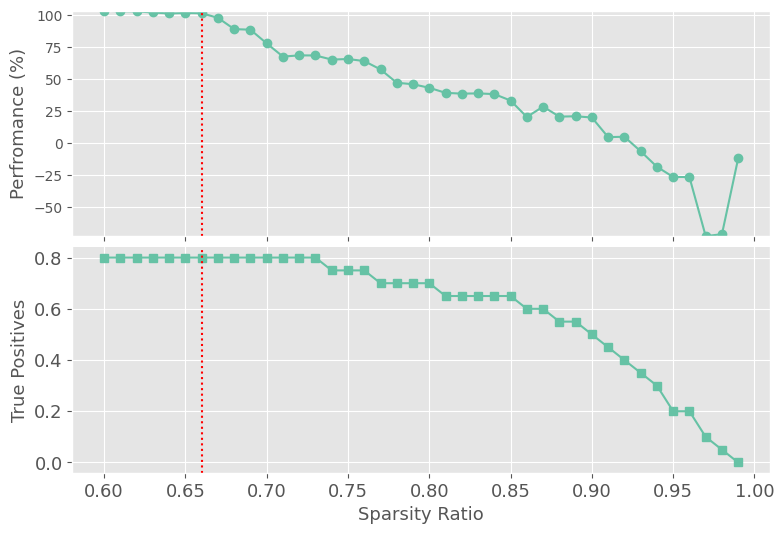

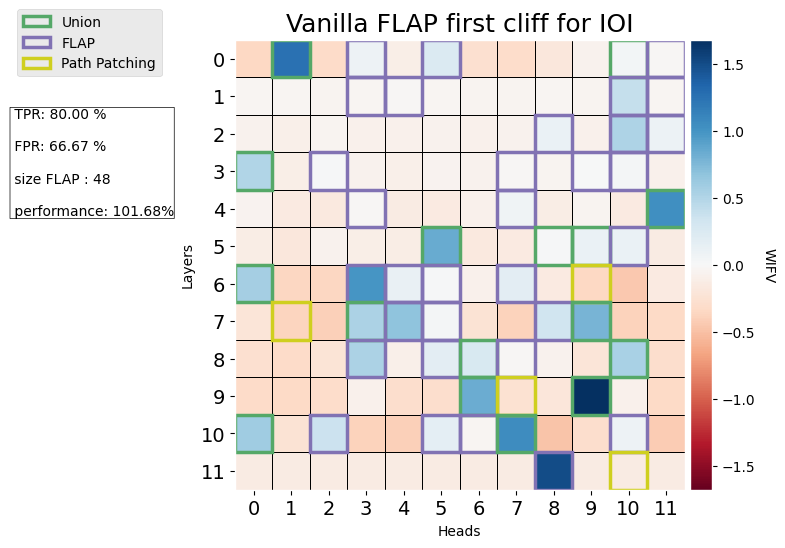

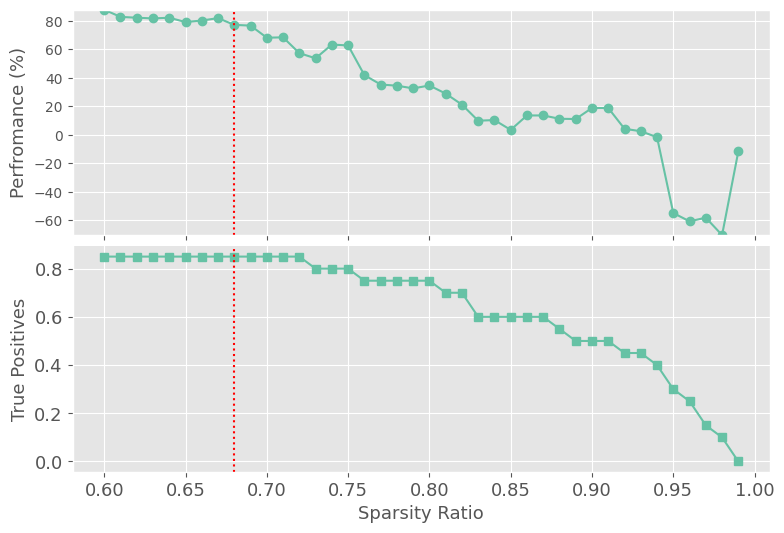

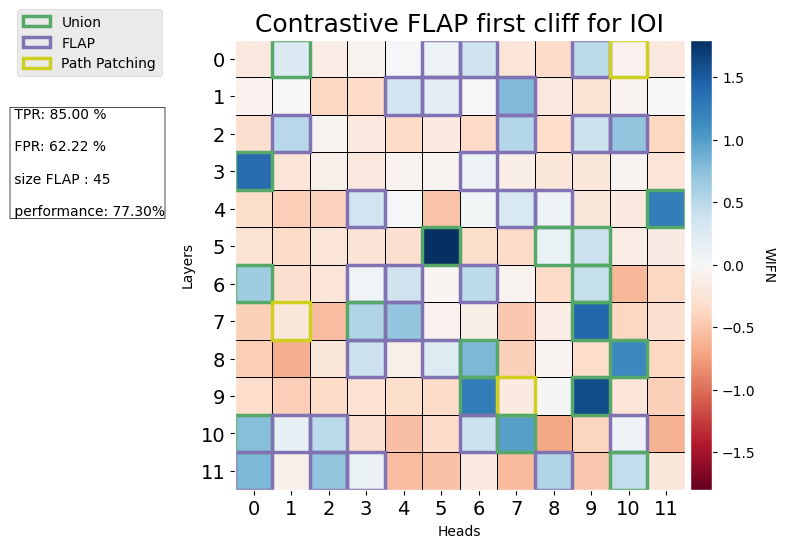

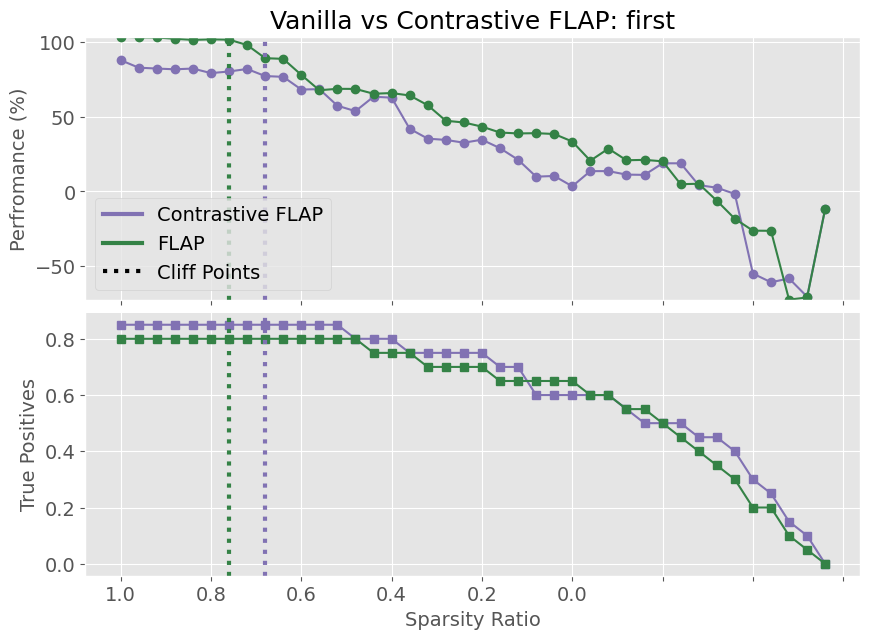

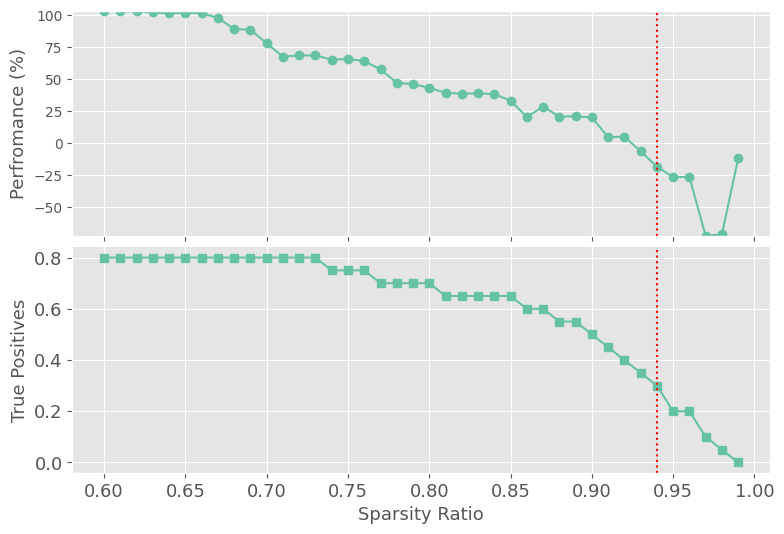

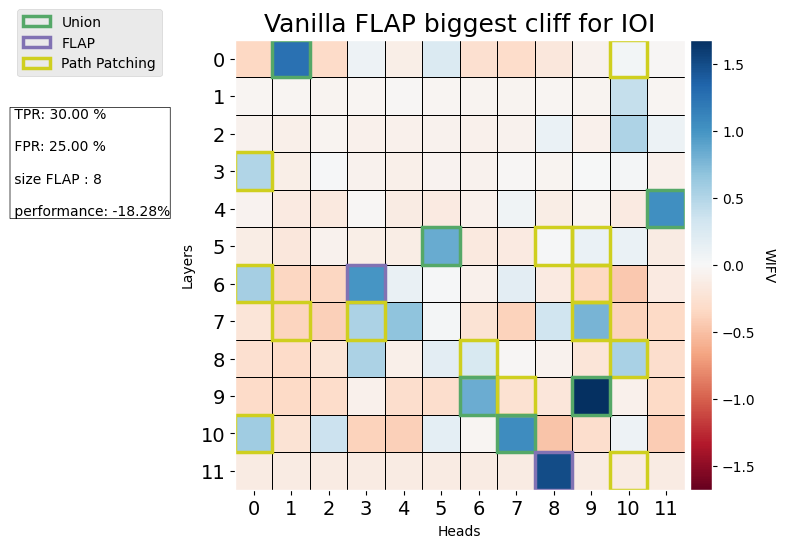

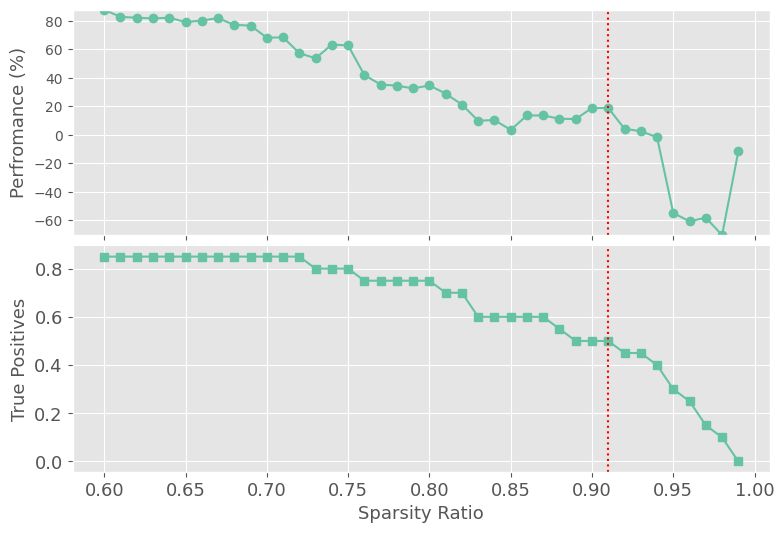

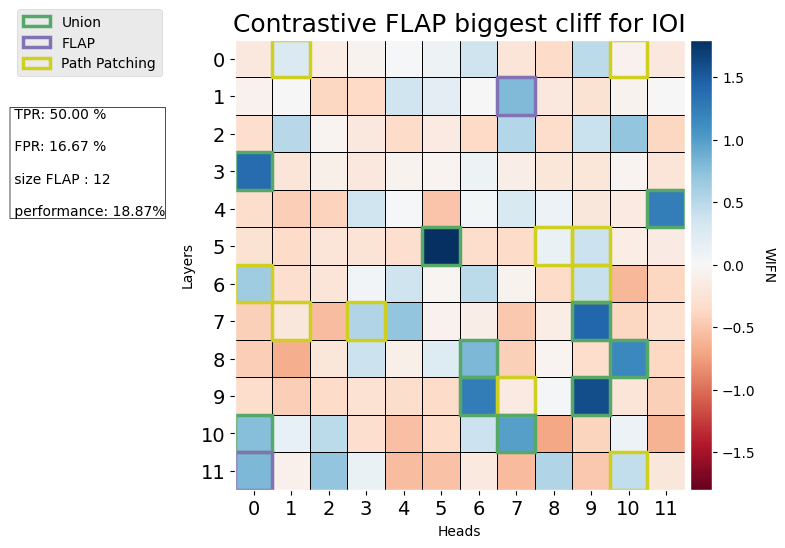

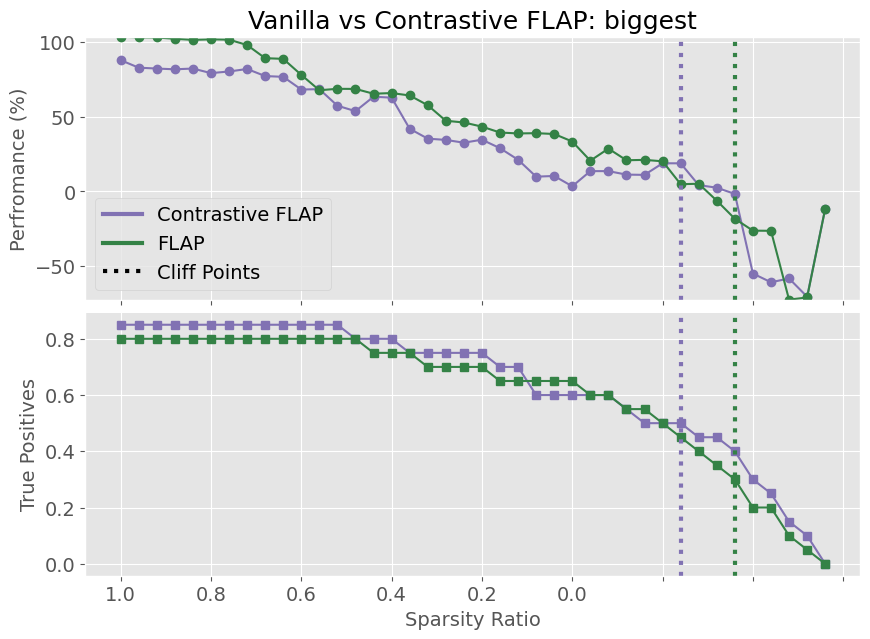

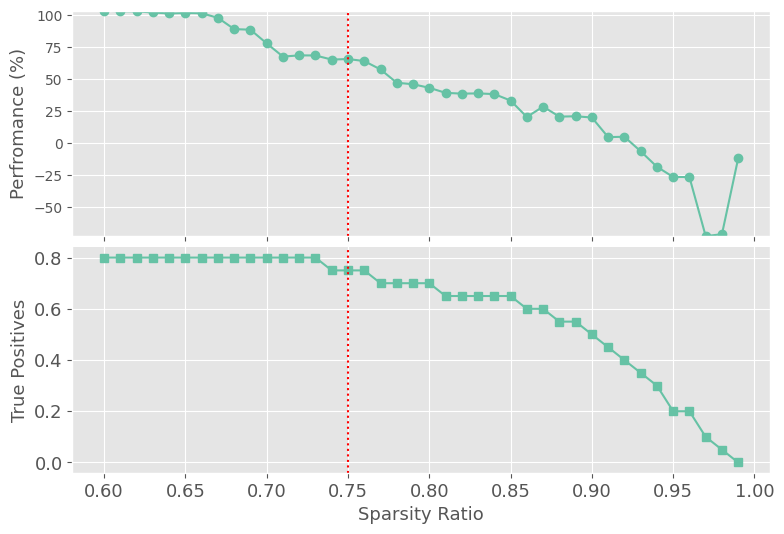

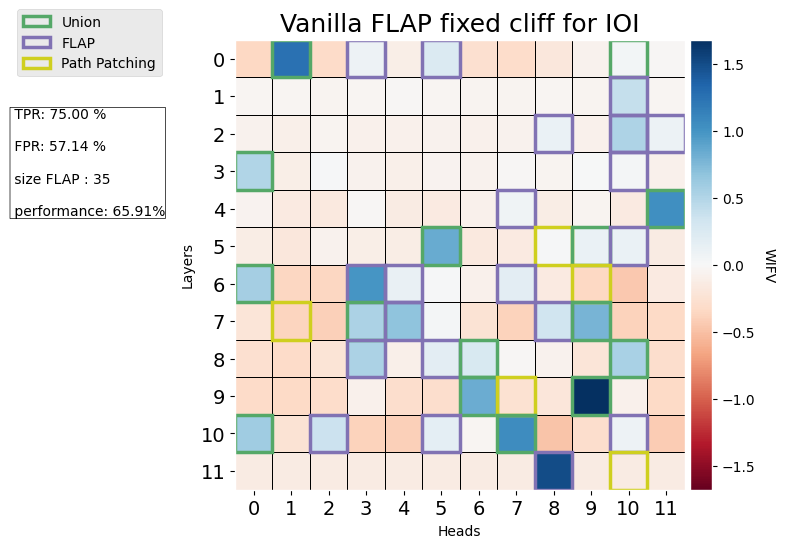

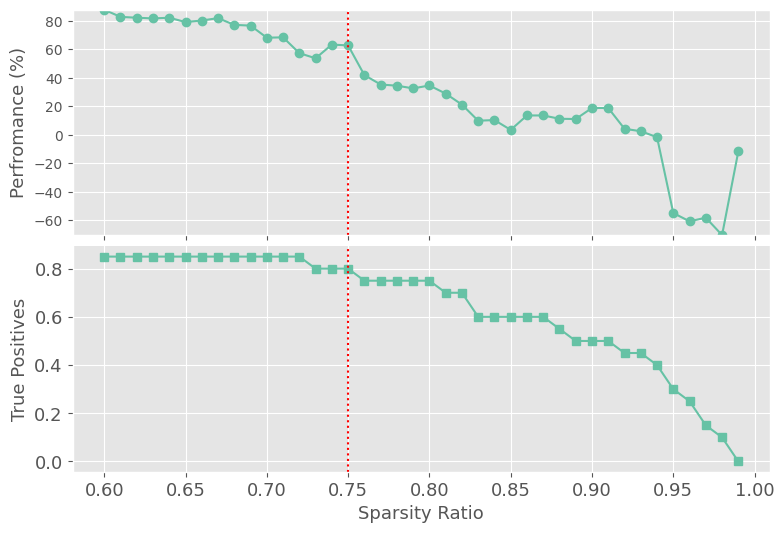

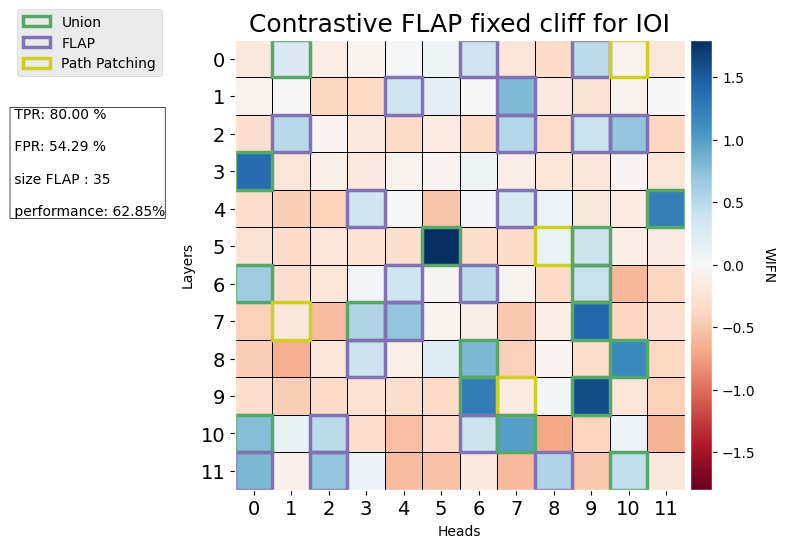

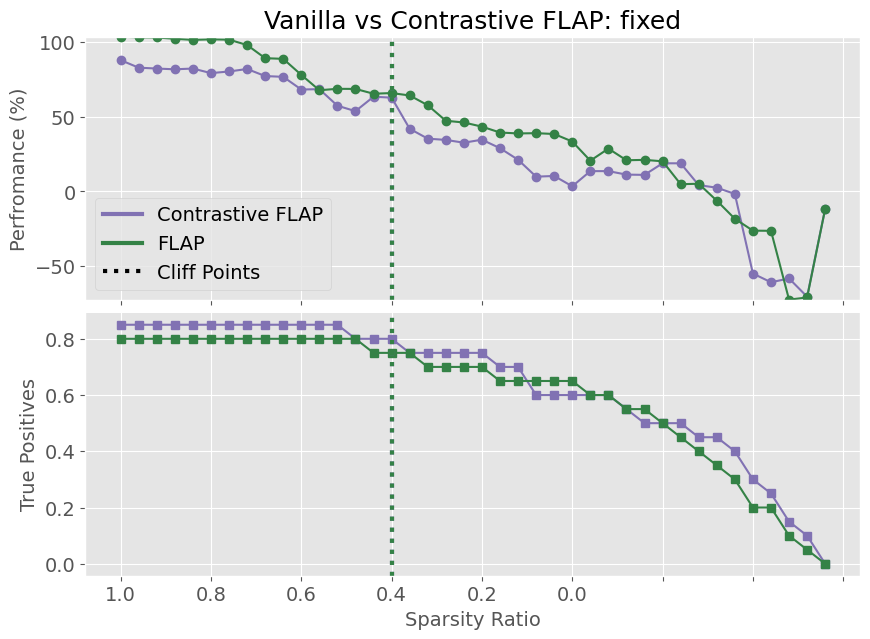

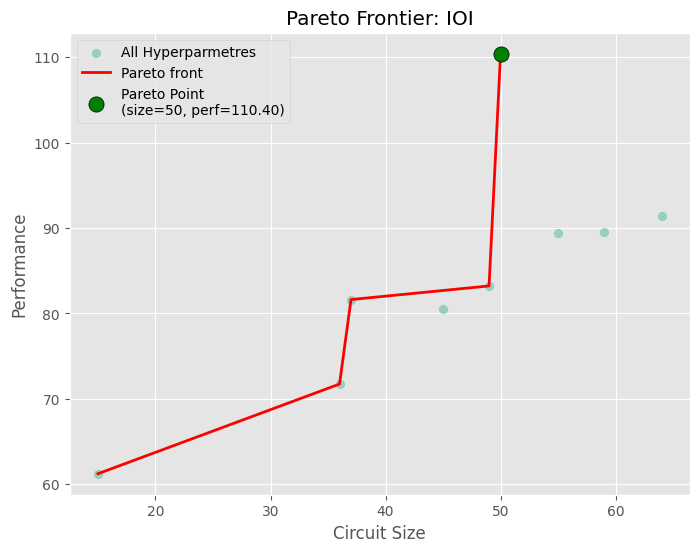

In [7]:
from Pruning.FLAP.lib.main import get_hybrid_FLAP_CIRCUIT

HYBRID_FLAP_CIRCUIT = get_hybrid_FLAP_CIRCUIT(args)

## ACDC

In [ ]:
from Patching.ACDC import ACDC

torch.autograd.set_grad_enabled(False)


subfolder = get_base_path(args, "ACDC")
acdc = ACDC(
    args,
    threshold = THRESHOLD,  # TODO: into parser
    second_metric=second_metric,
    reduced_search_space = HYBRID_FLAP_CIRCUIT,
    remove_redundant=remove_redundant,
    single_step=False,
    early_stop=False,
    indices_mode=INDICES_MODE,
    names_mode=NAMES_MODE,
    zero_ablation=ZERO_ABLATION,
    abs_value_threshold=ABS_VALUE_THRESHOLD,
    out_path=subfolder
    )  

loading gpt2 as HookedTransformer
use float 16
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
load gpt2 tokenizer
FLOP per forwad <fvcore.nn.flop_count.FlopCountAnalysis object at 0x7f0df09b0cd0>


blocks.0.attn.hook_attn_scores, blocks.0.attn.hook_k, blocks.0.attn.hook_pattern, blocks.0.attn.hook_q, blocks.0.attn.hook_result, blocks.0.attn.hook_v, blocks.0.attn.hook_z, blocks.0.hook_attn_in, blocks.0.hook_attn_out, blocks.0.hook_k_input, blocks.0.hook_mlp_in, blocks.0.hook_mlp_out, blocks.0.hook_q_input, blocks.0.hook_resid_mid, blocks.0.hook_resid_post, blocks.0.hook_resid_pre, blocks.0.hook_v_input, blocks.0.ln1.hook_normalized, blocks.0.ln1.hook_scale, blocks.0.ln2.hook_normalized, blocks.0.ln2.hook_scale, blocks.0.mlp.hook_post, blocks.0.mlp.hook_pre, blocks.1.attn.hook_attn_scores, blocks.1.attn.hook_k, blocks.1.attn.hook_pattern, blocks.1.attn.hook_q, blocks.1.attn.hook_result, blocks.1.attn.hook_v, blocks.1.attn.hook_z, blocks.1.hook_attn_in, blocks.1.hook_attn_out, blocks.1.hook_k_input, blocks.1.hook_mlp_in, blocks.1.hook_mlp_out, blocks.1.hook_q_input, blocks.1.hook_resid_mid, blocks.1.hook_resid_post, blocks.1.hook_resid_pre, blocks.1.hook_v_input, blocks.1.ln1.hook_n

heads for layer 11 : {8, 0}
skip head  11 because it is not in the reduced search space
skip head  10 because it is not in the reduced search space
skip head  9 because it is not in the reduced search space
skip head  7 because it is not in the reduced search space
skip head  6 because it is not in the reduced search space
skip head  5 because it is not in the reduced search space
skip head  4 because it is not in the reduced search space
skip head  3 because it is not in the reduced search space
skip head  2 because it is not in the reduced search space
skip head  1 because it is not in the reduced search space
heads for layer 10 : {0, 2, 5, 6, 7, 10}
skip head  11 because it is not in the reduced search space
skip head  9 because it is not in the reduced search space
skip head  8 because it is not in the reduced search space
skip head  4 because it is not in the reduced search space
skip head  3 because it is not in the reduced search space
skip head  1 because it is not in the reduc

In [57]:
acdc.run_exp(testing=False, max_epochs=100000, save_text=True)

We moved to  blocks.11.hook_mlp_in[:]
base name before /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48/ACDC_tau-0.0535_N-10.png
base name after /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48
base fname before /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48/ACDC_tau-0.0535_N-10.png
base fname after /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48
FNAME /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48
base name before /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48/tau-0.0535_N-10.png
base name after /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_test/corrupted/2026-03-27_18-26-48
base fname before /mnt/lustre/work/eickhoff/esx670/res_final//ACDC/accelerated/IOI_te